# DINOv2 Full-Dataset CLS Embedding Extraction

This notebook applies the configuration selected by the comprehensive evaluation to **every labeled grain** in the dataset.

**Final configuration**

`YOLO polygon crop → gray masked background → aspect-ratio padding → 518×518 → frozen DINOv2 ViT-S/14 → CLS embedding (384)`

It does **not** train a classifier and does **not** fine-tune DINOv2. Extraction is resumable and writes directly to a memory-mapped NumPy file so a stopped run does not lose completed work.

## 1. Server environment

Expected server locations:

- Notebook/project: `/home/multispector2/testdino`
- Dataset V2: `/home/multispector2/wheatv2/dataset_v2`

Activate the server environment before opening the notebook:

```bash
source /home/multispector2/testdino/.venv/bin/activate
```

Required packages: `torch torchvision numpy pandas opencv-python pillow pyyaml tqdm ipykernel`. The first model-loading run also needs network access to download the official DINOv2 repository and weights unless they are already cached.

In [1]:
from __future__ import annotations

import gc
import json
import math
import os
import random
import time
from functools import lru_cache
from pathlib import Path
from typing import Optional, Tuple

import cv2
import numpy as np
import pandas as pd
import torch
import yaml
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cuda.matmul.allow_tf32 = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Python process :", os.getpid())
print("PyTorch        :", torch.__version__)
print("Device         :", DEVICE)
if DEVICE.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print("GPU            :", torch.cuda.get_device_name(0))
    print(f"GPU memory     : {props.total_memory / 1024**3:.2f} GiB")

Python process : 3632951
PyTorch        : 2.13.0+cu126
Device         : cuda
GPU            : NVIDIA RTX 4000 SFF Ada Generation
GPU memory     : 19.55 GiB


/home/multispector2/testdino/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration

The server paths are selected automatically when they exist. Otherwise, the local Windows paths are used for validation.

In [2]:
SERVER_PROJECT_DIR = Path("/home/multispector2/testdino")
SERVER_DATASET_DIR = Path("/home/multispector2/wheatv2/dataset_v2")

LOCAL_PROJECT_DIR = Path(
    r"C:\Users\alool\Desktop\Codes\Python\Test_RFDeter"
    r"\notebooks_Test_DinoV2"
)
LOCAL_DATASET_DIR = Path(
    r"C:\Users\alool\Desktop\Codes\Python\Test_RFDeter"
    r"\dataset_v2"
)

if SERVER_DATASET_DIR.exists():
    RUN_ENVIRONMENT = "server"
    PROJECT_DIR = SERVER_PROJECT_DIR
    DATASET_DIR = SERVER_DATASET_DIR
elif LOCAL_DATASET_DIR.exists():
    RUN_ENVIRONMENT = "local_windows"
    PROJECT_DIR = LOCAL_PROJECT_DIR
    DATASET_DIR = LOCAL_DATASET_DIR
else:
    raise FileNotFoundError(
        "Dataset was not found at either configured location. "
        f"Server: {SERVER_DATASET_DIR} | Local: {LOCAL_DATASET_DIR}"
    )

OUTPUT_DIR = PROJECT_DIR / "dinov2_full_dataset_embeddings_v2"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_HUB_NAME = "dinov2_vits14"
MODEL_KEY = "vit_s14"
EMBEDDING_DIM = 384
IMAGE_SIZE = 518
PADDING_RATIO = 0.08
MASK_BACKGROUND = 127

LOADER_BATCH_SIZE = 64
INITIAL_GPU_MICROBATCH_SIZE = 64
NUM_WORKERS = 0 if os.name == "nt" else min(4, os.cpu_count() or 1)
CHECKPOINT_EVERY_GRAINS = 4096
RESUME = True
REQUIRE_CUDA = True

# Optional exports. NPY + metadata CSV are always produced.
CREATE_COMPRESSED_NPZ = False
CREATE_COMBINED_CSV = False
COMBINED_CSV_CHUNK_ROWS = 5000

MANIFEST_PATH = OUTPUT_DIR / "all_best_cls_manifest.csv"
METADATA_PATH = OUTPUT_DIR / "all_best_cls_metadata.csv"
EMBEDDINGS_PATH = OUTPUT_DIR / "all_best_cls_embeddings.npy"
STATE_PATH = OUTPUT_DIR / "extraction_state.json"
SUMMARY_PATH = OUTPUT_DIR / "extraction_summary.json"
NPZ_PATH = OUTPUT_DIR / "all_best_cls_embeddings_compressed.npz"
COMBINED_CSV_PATH = OUTPUT_DIR / "all_best_cls_embeddings_with_metadata.csv"

print("Environment :", RUN_ENVIRONMENT)
print("Dataset     :", DATASET_DIR)
print("Output      :", OUTPUT_DIR)
print("Workers     :", NUM_WORKERS)
print("Resume      :", RESUME)

if REQUIRE_CUDA and DEVICE.type != "cuda":
    raise RuntimeError(
        "CUDA is required for the full Dataset V2 grain extraction. "
        "Select the server GPU kernel, then rerun this notebook."
    )

Environment : server
Dataset     : /home/multispector2/wheatv2/dataset_v2
Output      : /home/multispector2/testdino/dinov2_full_dataset_embeddings_v2
Workers     : 4
Resume      : True


## 3. Discover and parse every YOLO segmentation instance

The manifest is deterministic and saved before embedding extraction. On restart, the saved manifest is reused so every row keeps the same `row_id`.

In [3]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}


def read_class_names(dataset_dir: Path):
    yaml_candidates = sorted(dataset_dir.glob("*.yaml")) + sorted(dataset_dir.glob("*.yml"))

    for yaml_path in yaml_candidates:
        config = yaml.safe_load(yaml_path.read_text(encoding="utf-8")) or {}
        names = config.get("names")

        if isinstance(names, list):
            return {index: str(name) for index, name in enumerate(names)}, yaml_path

        if isinstance(names, dict):
            return {int(key): str(value) for key, value in names.items()}, yaml_path

    return {}, None


def find_split_pairs(dataset_dir: Path):
    aliases = [("train", "train"), ("valid", "valid"), ("val", "val"), ("test", "test")]
    found = []

    for split_name, folder in aliases:
        image_dir = dataset_dir / folder / "images"
        label_dir = dataset_dir / folder / "labels"
        if image_dir.exists() and label_dir.exists():
            found.append((split_name, image_dir, label_dir))

    for split_name, folder in aliases:
        image_dir = dataset_dir / "images" / folder
        label_dir = dataset_dir / "labels" / folder
        candidate = (split_name, image_dir, label_dir)
        if image_dir.exists() and label_dir.exists() and candidate not in found:
            found.append(candidate)

    return found


def parse_yolo_segmentation_line(line: str):
    parts = line.strip().split()
    if len(parts) < 7:
        return None

    class_id = int(float(parts[0]))
    coordinates = np.asarray([float(value) for value in parts[1:]], dtype=np.float32)

    if len(coordinates) % 2 != 0:
        return None

    return class_id, coordinates.reshape(-1, 2)


CLASS_NAMES, YAML_PATH = read_class_names(DATASET_DIR)
SPLIT_DIRS = find_split_pairs(DATASET_DIR)

if not SPLIT_DIRS:
    raise FileNotFoundError(
        "Could not find YOLO image/label folders under the configured dataset directory."
    )

print("YAML   :", YAML_PATH)
print("Classes:", CLASS_NAMES)
for split_name, image_dir, label_dir in SPLIT_DIRS:
    print(f"{split_name:>5} | images={image_dir} | labels={label_dir}")

if MANIFEST_PATH.exists() and RESUME:
    print("Loading saved manifest:", MANIFEST_PATH)
    manifest_df = pd.read_csv(MANIFEST_PATH)
    manifest_df["polygon_px"] = manifest_df["polygon_px"].apply(
        lambda value: np.asarray(json.loads(value), dtype=np.float32)
    )
else:
    records = []

    for split_name, image_dir, label_dir in SPLIT_DIRS:
        image_paths = sorted(
            path for path in image_dir.rglob("*")
            if path.suffix.lower() in IMAGE_EXTENSIONS
        )

        for image_path in tqdm(image_paths, desc=f"Parse {split_name}", unit="image"):
            label_path = label_dir / f"{image_path.stem}.txt"

            if not label_path.exists():
                relative_label = image_path.relative_to(image_dir).with_suffix(".txt")
                label_path = label_dir / relative_label

            if not label_path.exists():
                continue

            with Image.open(image_path) as image:
                width, height = image.size

            lines = label_path.read_text(encoding="utf-8", errors="ignore").splitlines()

            for instance_idx, line in enumerate(lines):
                parsed = parse_yolo_segmentation_line(line)
                if parsed is None:
                    continue

                class_id, polygon_norm = parsed
                polygon_px = polygon_norm.copy()
                polygon_px[:, 0] *= width
                polygon_px[:, 1] *= height

                records.append({
                    "split": split_name,
                    "image_path": str(image_path),
                    "label_path": str(label_path),
                    "instance_idx": int(instance_idx),
                    "class_id": int(class_id),
                    "class_name": CLASS_NAMES.get(class_id, f"class_{class_id}"),
                    "polygon_px": polygon_px,
                })

    manifest_df = pd.DataFrame(records)
    if manifest_df.empty:
        raise ValueError("No YOLO segmentation instances were parsed.")

    manifest_df.insert(0, "row_id", np.arange(len(manifest_df), dtype=np.int64))

    manifest_to_save = manifest_df.copy()
    manifest_to_save["polygon_px"] = manifest_to_save["polygon_px"].apply(
        lambda polygon: json.dumps(np.asarray(polygon, dtype=float).tolist())
    )
    manifest_to_save.to_csv(MANIFEST_PATH, index=False)
    print("Saved manifest:", MANIFEST_PATH)

expected_row_ids = np.arange(len(manifest_df), dtype=np.int64)
if not np.array_equal(manifest_df["row_id"].to_numpy(dtype=np.int64), expected_row_ids):
    raise ValueError("Manifest row_id values are not contiguous and deterministic.")

metadata_columns = [
    "row_id", "split", "image_path", "label_path",
    "instance_idx", "class_id", "class_name",
]
manifest_df[metadata_columns].to_csv(METADATA_PATH, index=False)

print("Unique images :", manifest_df["image_path"].nunique())
print("Grain instances:", len(manifest_df))
display(
    manifest_df.groupby(["split", "class_id", "class_name"])
    .size()
    .reset_index(name="instances")
)

YAML   : /home/multispector2/wheatv2/dataset_v2/data.yaml
Classes: {0: 'bad seed', 1: 'healthy seed', 2: 'impurity'}
train | images=/home/multispector2/wheatv2/dataset_v2/train/images | labels=/home/multispector2/wheatv2/dataset_v2/train/labels
valid | images=/home/multispector2/wheatv2/dataset_v2/valid/images | labels=/home/multispector2/wheatv2/dataset_v2/valid/labels
 test | images=/home/multispector2/wheatv2/dataset_v2/test/images | labels=/home/multispector2/wheatv2/dataset_v2/test/labels


Parse test: 100%|██████████| 299/299 [00:00<00:00, 675.79image/s]


Saved manifest: /home/multispector2/testdino/dinov2_full_dataset_embeddings_v2/all_best_cls_manifest.csv
Unique images : 2996
Grain instances: 222939


,split,class_id,class_name,instances
0,test,0,bad seed,17074
1,test,1,healthy seed,6308
2,test,2,impurity,48
3,train,0,bad seed,105729
4,train,1,healthy seed,47628
5,train,2,impurity,332
6,valid,0,bad seed,31246
7,valid,1,healthy seed,14488
8,valid,2,impurity,86


## 4. Final preprocessing pipeline

Only the winning preprocessing is used: original grain colors, masked gray background, aspect-ratio-preserving padding, and standard DINOv2/ImageNet input normalization.

Test crop   : (106, 45)
Test tensor : (3, 518, 518) torch.float32


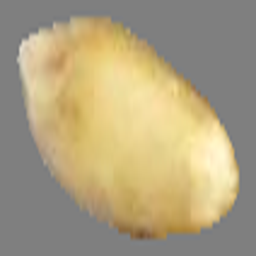

In [4]:
@lru_cache(maxsize=64)
def read_rgb_cached(image_path: str) -> np.ndarray:
    image_bgr = cv2.imread(image_path, cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise ValueError(f"Could not read image: {image_path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def extract_masked_crop(
    image_path: str,
    polygon_px: np.ndarray,
    padding_ratio: float = PADDING_RATIO,
) -> Image.Image:
    image_rgb = read_rgb_cached(str(image_path))
    height, width = image_rgb.shape[:2]
    polygon = np.round(np.asarray(polygon_px)).astype(np.int32)

    x, y, box_width, box_height = cv2.boundingRect(polygon)
    pad_x = int(round(box_width * padding_ratio))
    pad_y = int(round(box_height * padding_ratio))

    x1 = max(0, x - pad_x)
    y1 = max(0, y - pad_y)
    x2 = min(width, x + box_width + pad_x)
    y2 = min(height, y + box_height + pad_y)

    if x2 <= x1 or y2 <= y1:
        raise ValueError(f"Empty crop for image {image_path}")

    crop = image_rgb[y1:y2, x1:x2].copy()
    local_polygon = polygon.copy()
    local_polygon[:, 0] -= x1
    local_polygon[:, 1] -= y1

    mask = np.zeros(crop.shape[:2], dtype=np.uint8)
    cv2.fillPoly(mask, [local_polygon], 255)

    background = np.full_like(crop, MASK_BACKGROUND)
    masked = np.where(mask[..., None] > 0, crop, background).astype(np.uint8)
    return Image.fromarray(masked)


def pad_to_square(image: Image.Image) -> Image.Image:
    width, height = image.size
    side = max(width, height)
    canvas = Image.new(
        "RGB",
        (side, side),
        color=(MASK_BACKGROUND, MASK_BACKGROUND, MASK_BACKGROUND),
    )
    canvas.paste(image, ((side - width) // 2, (side - height) // 2))
    return canvas


DINO_NORMALIZE = transforms.Normalize(
    mean=(0.485, 0.456, 0.406),
    std=(0.229, 0.224, 0.225),
)
TO_TENSOR = transforms.ToTensor()


def prepare_dino_tensor(image: Image.Image) -> torch.Tensor:
    image = pad_to_square(image)
    image = image.resize((IMAGE_SIZE, IMAGE_SIZE), resample=Image.Resampling.BICUBIC)
    return DINO_NORMALIZE(TO_TENSOR(image))


class FullGrainDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, start_row: int = 0):
        self.df = dataframe.iloc[start_row:].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index: int):
        row = self.df.iloc[index]
        crop = extract_masked_crop(row["image_path"], row["polygon_px"])
        tensor = prepare_dino_tensor(crop)
        return tensor, np.int64(row["row_id"])


# Small read/preprocessing smoke test before loading the model.
test_row = manifest_df.iloc[0]
test_crop = extract_masked_crop(test_row["image_path"], test_row["polygon_px"])
test_tensor = prepare_dino_tensor(test_crop)
print("Test crop   :", test_crop.size)
print("Test tensor :", tuple(test_tensor.shape), test_tensor.dtype)
display(test_crop.resize((256, 256)))

## 5. Load frozen pretrained DINOv2 ViT-S/14

In [5]:
gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

model = torch.hub.load(
    "facebookresearch/dinov2",
    MODEL_HUB_NAME,
    pretrained=True,
)
model = model.to(DEVICE).eval()

for parameter in model.parameters():
    parameter.requires_grad = False

parameter_count = sum(parameter.numel() for parameter in model.parameters())
trainable_count = sum(
    parameter.numel() for parameter in model.parameters() if parameter.requires_grad
)

print("Model                :", MODEL_HUB_NAME)
print(f"Parameters           : {parameter_count / 1e6:.2f}M")
print("Trainable parameters :", trainable_count)

with torch.inference_mode():
    test_batch = test_tensor.unsqueeze(0).to(DEVICE)
    with torch.autocast(
        device_type=DEVICE.type,
        dtype=torch.float16,
        enabled=(DEVICE.type == "cuda"),
    ):
        test_features = model.forward_features(test_batch)
        test_embedding = test_features["x_norm_clstoken"]

if test_embedding.shape[1] != EMBEDDING_DIM:
    raise ValueError(
        f"Expected {EMBEDDING_DIM} CLS features, got {test_embedding.shape[1]}"
    )

print("CLS test shape       :", tuple(test_embedding.shape))
del test_batch, test_features, test_embedding
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /home/multispector2/.cache/torch/hub/main.zip


/home/multispector2/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/multispector2/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/multispector2/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /home/multispector2/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 112MB/s] 


Model                : dinov2_vits14
Parameters           : 22.06M
Trainable parameters : 0
CLS test shape       : (1, 384)


## 6. Resumable full extraction

Safe behavior:

- New run: creates `all_best_cls_embeddings.npy`.
- Interrupted run: rerun this cell to continue from `extraction_state.json`.
- Completed run: rerunning the cell skips extraction.
- CUDA OOM: automatically reduces the GPU microbatch size.

In [6]:
def write_state_atomic(state: dict):
    temporary_path = STATE_PATH.with_suffix(".json.tmp")
    temporary_path.write_text(json.dumps(state, indent=2), encoding="utf-8")
    temporary_path.replace(STATE_PATH)


def load_or_create_state(total_rows: int):
    expected = {
        "dataset_dir": str(DATASET_DIR),
        "model": MODEL_HUB_NAME,
        "preprocessing": "original_masked_aspect_pad_518",
        "embedding_type": "cls",
        "embedding_dim": EMBEDDING_DIM,
        "total_rows": total_rows,
    }

    if STATE_PATH.exists() and RESUME:
        state = json.loads(STATE_PATH.read_text(encoding="utf-8"))
        for key, expected_value in expected.items():
            if state.get(key) != expected_value:
                raise ValueError(
                    f"Existing extraction state mismatch for {key}: "
                    f"{state.get(key)!r} != {expected_value!r}. "
                    "Use a different OUTPUT_DIR rather than mixing runs."
                )
        return state

    if EMBEDDINGS_PATH.exists():
        raise FileExistsError(
            f"{EMBEDDINGS_PATH} exists without a reusable state file. "
            "Move it to a safe backup or choose a new OUTPUT_DIR."
        )

    state = {
        **expected,
        "next_row": 0,
        "status": "initialized",
        "gpu_microbatch_size": INITIAL_GPU_MICROBATCH_SIZE,
        "created_at_unix": time.time(),
        "updated_at_unix": time.time(),
    }
    write_state_atomic(state)
    return state


def forward_cls_with_oom_retry(images_cpu: torch.Tensor, microbatch_size: int):
    outputs = []
    cursor = 0
    working_size = min(microbatch_size, len(images_cpu))

    while cursor < len(images_cpu):
        current_size = min(working_size, len(images_cpu) - cursor)

        try:
            images = images_cpu[cursor:cursor + current_size].to(
                DEVICE, non_blocking=True
            )

            with torch.inference_mode():
                with torch.autocast(
                    device_type=DEVICE.type,
                    dtype=torch.float16,
                    enabled=(DEVICE.type == "cuda"),
                ):
                    features = model.forward_features(images)
                    cls_embedding = features["x_norm_clstoken"]

            outputs.append(cls_embedding.float().cpu().numpy())
            del images, features, cls_embedding
            cursor += current_size

        except torch.cuda.OutOfMemoryError:
            if DEVICE.type != "cuda":
                raise

            torch.cuda.empty_cache()
            gc.collect()
            working_size //= 2

            if working_size < 1:
                raise RuntimeError("CUDA OOM even at microbatch size 1.")

            print(
                f"CUDA OOM: retrying with GPU microbatch size {working_size}",
                flush=True,
            )

    return np.concatenate(outputs, axis=0), working_size


total_rows = len(manifest_df)
state = load_or_create_state(total_rows)
start_row = int(state["next_row"])

if not 0 <= start_row <= total_rows:
    raise ValueError(f"Invalid resume row {start_row} for {total_rows} total rows.")

if EMBEDDINGS_PATH.exists():
    embedding_store = np.load(EMBEDDINGS_PATH, mmap_mode="r+")
    if embedding_store.shape != (total_rows, EMBEDDING_DIM):
        raise ValueError(
            f"Existing embedding shape {embedding_store.shape} does not match "
            f"{(total_rows, EMBEDDING_DIM)}"
        )
    if embedding_store.dtype != np.float32:
        raise ValueError(f"Expected float32 embeddings, got {embedding_store.dtype}")
else:
    if start_row != 0:
        raise FileNotFoundError("State requests resume, but the NPY file is missing.")
    embedding_store = np.lib.format.open_memmap(
        EMBEDDINGS_PATH,
        mode="w+",
        dtype=np.float32,
        shape=(total_rows, EMBEDDING_DIM),
    )
    embedding_store.flush()

if start_row == total_rows:
    print("Extraction is already complete.")
else:
    remaining_dataset = FullGrainDataset(manifest_df, start_row=start_row)

    loader_kwargs = {
        "dataset": remaining_dataset,
        "batch_size": LOADER_BATCH_SIZE,
        "shuffle": False,
        "num_workers": NUM_WORKERS,
        "pin_memory": (DEVICE.type == "cuda"),
    }
    if NUM_WORKERS > 0:
        loader_kwargs.update({"persistent_workers": True, "prefetch_factor": 2})

    grain_loader = DataLoader(**loader_kwargs)
    next_row = start_row
    last_checkpoint_row = start_row
    microbatch_size = int(state.get("gpu_microbatch_size", INITIAL_GPU_MICROBATCH_SIZE))
    started_at = time.perf_counter()

    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats()

    progress = tqdm(
        total=total_rows,
        initial=start_row,
        desc="Full DINOv2 CLS extraction",
        unit="grain",
        dynamic_ncols=True,
    )

    try:
        for images_cpu, row_ids_batch in grain_loader:
            row_ids_numpy = row_ids_batch.numpy().astype(np.int64, copy=False)
            expected_ids = np.arange(next_row, next_row + len(row_ids_numpy), dtype=np.int64)

            if not np.array_equal(row_ids_numpy, expected_ids):
                raise ValueError(
                    f"Row alignment failure. Expected {expected_ids[:3]}, "
                    f"received {row_ids_numpy[:3]}."
                )

            batch_embeddings, microbatch_size = forward_cls_with_oom_retry(
                images_cpu, microbatch_size
            )

            if batch_embeddings.shape != (len(row_ids_numpy), EMBEDDING_DIM):
                raise ValueError(f"Unexpected batch embedding shape: {batch_embeddings.shape}")

            embedding_store[row_ids_numpy] = batch_embeddings
            next_row += len(row_ids_numpy)
            progress.update(len(row_ids_numpy))

            if (
                next_row - last_checkpoint_row >= CHECKPOINT_EVERY_GRAINS
                or next_row == total_rows
            ):
                embedding_store.flush()
                state.update({
                    "next_row": next_row,
                    "status": "complete" if next_row == total_rows else "running",
                    "gpu_microbatch_size": microbatch_size,
                    "updated_at_unix": time.time(),
                })
                write_state_atomic(state)
                last_checkpoint_row = next_row

    except KeyboardInterrupt:
        embedding_store.flush()
        state.update({
            "next_row": next_row,
            "status": "interrupted",
            "gpu_microbatch_size": microbatch_size,
            "updated_at_unix": time.time(),
        })
        write_state_atomic(state)
        print(f"Saved interruption checkpoint at row {next_row}.", flush=True)
        raise
    finally:
        progress.close()

    elapsed = time.perf_counter() - started_at
    embedding_store.flush()
    state.update({
        "next_row": next_row,
        "status": "complete" if next_row == total_rows else state.get("status", "stopped"),
        "gpu_microbatch_size": microbatch_size,
        "updated_at_unix": time.time(),
        "last_session_elapsed_sec": elapsed,
    })
    if DEVICE.type == "cuda":
        state["peak_gpu_mb"] = torch.cuda.max_memory_allocated() / 1024**2
    write_state_atomic(state)

    print("Extraction status :", state["status"])
    print("Completed rows    :", f"{next_row:,} / {total_rows:,}")
    print("Last session time :", f"{elapsed / 60:.2f} minutes")
    print("Final NPY         :", EMBEDDINGS_PATH)

Full DINOv2 CLS extraction: 100%|██████████| 222939/222939 [21:17<00:00, 174.47grain/s]

Extraction status : complete
Completed rows    : 222,939 / 222,939
Last session time : 21.30 minutes
Final NPY         : /home/multispector2/testdino/dinov2_full_dataset_embeddings_v2/all_best_cls_embeddings.npy


## 7. Validate the completed output

This scans the final NPY in chunks, verifies that every value is finite, measures row norms, and writes a JSON summary.

In [7]:
state = json.loads(STATE_PATH.read_text(encoding="utf-8"))
if state.get("status") != "complete" or int(state.get("next_row", -1)) != len(manifest_df):
    raise RuntimeError(
        f"Extraction is not complete: status={state.get('status')}, "
        f"next_row={state.get('next_row')}. Rerun the extraction cell first."
    )

embeddings = np.load(EMBEDDINGS_PATH, mmap_mode="r")
if embeddings.shape != (len(manifest_df), EMBEDDING_DIM):
    raise ValueError(f"Final embedding shape is incorrect: {embeddings.shape}")

scan_chunk = 25000
nonfinite_count = 0
row_norm_sum = 0.0
row_norm_min = math.inf
row_norm_max = -math.inf

for start in tqdm(range(0, len(embeddings), scan_chunk), desc="Validate NPY", unit="chunk"):
    block = np.asarray(embeddings[start:start + scan_chunk])
    nonfinite_count += int((~np.isfinite(block)).sum())
    norms = np.linalg.norm(block, axis=1)
    row_norm_sum += float(norms.sum(dtype=np.float64))
    row_norm_min = min(row_norm_min, float(norms.min()))
    row_norm_max = max(row_norm_max, float(norms.max()))

if nonfinite_count != 0:
    raise ValueError(f"Found {nonfinite_count} NaN/Inf values in the final embeddings.")

class_counts = (
    manifest_df.groupby(["class_id", "class_name"])
    .size()
    .reset_index(name="count")
)

summary = {
    "status": "complete",
    "dataset_dir": str(DATASET_DIR),
    "output_dir": str(OUTPUT_DIR),
    "model": MODEL_HUB_NAME,
    "frozen": True,
    "normalization": "original_color_plus_standard_dino_imagenet_normalization",
    "resize_mode": "aspect_pad",
    "embedding_type": "cls",
    "embedding_shape": list(embeddings.shape),
    "embedding_dtype": str(embeddings.dtype),
    "nonfinite_values": nonfinite_count,
    "mean_row_l2_norm": row_norm_sum / len(embeddings),
    "min_row_l2_norm": row_norm_min,
    "max_row_l2_norm": row_norm_max,
    "unique_source_images": int(manifest_df["image_path"].nunique()),
    "class_counts": class_counts.to_dict(orient="records"),
    "files": {
        "embeddings_npy": str(EMBEDDINGS_PATH),
        "metadata_csv": str(METADATA_PATH),
        "manifest_csv": str(MANIFEST_PATH),
    },
}
SUMMARY_PATH.write_text(json.dumps(summary, indent=2), encoding="utf-8")

print(json.dumps(summary, indent=2))
display(class_counts)
print("NPY size      :", f"{EMBEDDINGS_PATH.stat().st_size / 1024**2:.2f} MiB")
print("Metadata size :", f"{METADATA_PATH.stat().st_size / 1024**2:.2f} MiB")

Validate NPY: 100%|██████████| 9/9 [00:00<00:00, 43.55chunk/s]

{
  "status": "complete",
  "dataset_dir": "/home/multispector2/wheatv2/dataset_v2",
  "output_dir": "/home/multispector2/testdino/dinov2_full_dataset_embeddings_v2",
  "model": "dinov2_vits14",
  "frozen": true,
  "normalization": "original_color_plus_standard_dino_imagenet_normalization",
  "resize_mode": "aspect_pad",
  "embedding_type": "cls",
  "embedding_shape": [
    222939,
    384
  ],
  "embedding_dtype": "float32",
  "nonfinite_values": 0,
  "mean_row_l2_norm": 47.90716795275195,
  "min_row_l2_norm": 42.82944869995117,
  "max_row_l2_norm": 51.24493408203125,
  "unique_source_images": 2996,
  "class_counts": [
    {
      "class_id": 0,
      "class_name": "bad seed",
      "count": 154049
    },
    {
      "class_id": 1,
      "class_name": "healthy seed",
      "count": 68424
    },
    {
      "class_id": 2,
      "class_name": "impurity",
      "count": 466
    }
  ],
  "files": {
    "embeddings_npy": "/home/multispector2/testdino/dinov2_full_dataset_embeddings_v2/all_b

,class_id,class_name,count
0,0,bad seed,154049
1,1,healthy seed,68424
2,2,impurity,466


NPY size      : 326.57 MiB
Metadata size : 51.45 MiB


## 8. Optional compressed NPZ export

The NPY file is the recommended training format because it supports memory mapping. Set `CREATE_COMPRESSED_NPZ = True` in the configuration if a smaller transfer file is also needed. Compression can take several minutes.

In [8]:
if CREATE_COMPRESSED_NPZ:
    embeddings = np.load(EMBEDDINGS_PATH, mmap_mode="r")
    row_ids = manifest_df["row_id"].to_numpy(dtype=np.int64)

    print("Creating compressed NPZ. This may take several minutes...", flush=True)
    np.savez_compressed(
        NPZ_PATH,
        cls=embeddings,
        row_ids=row_ids,
    )
    print("Saved:", NPZ_PATH)
    print("Size :", f"{NPZ_PATH.stat().st_size / 1024**2:.2f} MiB")
else:
    print("Compressed NPZ skipped. The complete NPY file is already available.")

Compressed NPZ skipped. The complete NPY file is already available.


## 9. Optional combined CSV export

Set `CREATE_COMBINED_CSV = True` only if a human-readable file containing metadata plus all 384 values is required. The CSV can approach or exceed 1 GB and is not recommended for model training.

In [10]:
if CREATE_COMBINED_CSV:
    embeddings = np.load(EMBEDDINGS_PATH, mmap_mode="r")
    metadata = pd.read_csv(METADATA_PATH)
    feature_columns = [f"cls_feature_{index:03d}" for index in range(EMBEDDING_DIM)]

    print("Writing combined CSV in chunks...", flush=True)
    for start in tqdm(
        range(0, len(metadata), COMBINED_CSV_CHUNK_ROWS),
        desc="Combined CSV",
        unit="chunk",
    ):
        stop = min(start + COMBINED_CSV_CHUNK_ROWS, len(metadata))
        feature_block = pd.DataFrame(
            np.asarray(embeddings[start:stop]),
            columns=feature_columns,
        )
        output_block = pd.concat(
            [
                metadata.iloc[start:stop].reset_index(drop=True),
                feature_block,
            ],
            axis=1,
        )
        output_block.to_csv(
            COMBINED_CSV_PATH,
            mode="w" if start == 0 else "a",
            header=(start == 0),
            index=False,
            float_format="%.9g",
        )

    print("Saved:", COMBINED_CSV_PATH)
    print("Size :", f"{COMBINED_CSV_PATH.stat().st_size / 1024**2:.2f} MiB")
else:
    print("Combined CSV skipped. Use the NPY + metadata CSV for ML.")

Combined CSV skipped. Use the NPY + metadata CSV for ML.


## 10. Loading the final data for downstream ML

```python
import numpy as np
import pandas as pd

X = np.load("dinov2_full_dataset_embeddings_v2/all_best_cls_embeddings.npy", mmap_mode="r")
metadata = pd.read_csv("dinov2_full_dataset_embeddings_v2/all_best_cls_metadata.csv")
y = metadata["class_id"].to_numpy()
groups = metadata["image_path"].to_numpy()

print(X.shape, y.shape)
```

For final classifier evaluation, split by recording/session/batch where possible. At minimum, use `image_path` as a group so grains from the same source image never appear in both training and evaluation data.